<div style="background:#1E2664;color:#ffffff;padding:22px 26px;border-radius:10px;font-family:Calibri,Arial,sans-serif;">
  <div style="font-size:13px;letter-spacing:2px;color:#0FA3B1;font-weight:700;">UNIVERSIDAD AUT&Oacute;NOMA DE GUADALAJARA</div>
  <div style="font-size:26px;font-weight:700;margin-top:6px;">Práctica de repaso — Primer Parcial · SOLUCIÓN</div>
  <div style="font-size:16px;margin-top:4px;color:#d6d9ec;">Unidad 3 (Tuberías de aprendizaje automático) y Unidad 4 (Ingeniería de funciones)</div>
  <div style="margin-top:14px;font-size:14px;">
    <span style="background:#E8912B;padding:4px 12px;border-radius:14px;font-weight:700;">FP13 &middot; Inteligencia Artificial</span>
  </div>
</div>

### Cómo usar esta práctica

Esta práctica recorre **los mismos ocho puntos de decisión que evalúa el examen**, en el mismo orden.
<br>
Lo que cambiará en el examen es el conjunto de datos: **las propiedades serán distintas y, por lo tanto,
varias decisiones correctas serán otras**.

---

### Contexto clínico

Registro de una **cohorte de insuficiencia cardiaca crónica**. Cada fila es un paciente.
Objetivo: predecir `reingreso_30d`.

| Variable | Tipo | Descripción |
|---|---|---|
| `id_paciente` | Texto | Identificador |
| `edad` | Numérica | Años cumplidos |
| `sexo` | Categórica nominal | M / F |
| `frec_cardiaca` | Numérica | Frecuencia cardiaca (lpm) |
| `presion_sistolica` | Numérica | Presión arterial sistólica (mmHg) |
| `bnp` | Numérica | Péptido natriurético tipo B (pg/mL) |
| `creatinina` | Numérica | Creatinina sérica (mg/dL) |
| `colesterol_total` | Numérica | Colesterol total (mg/dL) |
| `fevi_ingreso` | Numérica | Fracción de eyección (%) — *reservada para el reto final* |
| `tipo_dolor` | Categórica nominal | TA / AA / DNA / ASINT |
| `pendiente_st` | Categórica nominal | Ascendente / Plana / Descendente |
| `reingreso_30d` | Binaria | **Variable objetivo** |


In [1]:
# ============================================================
#  CELDA DADA — ejecútala sin modificarla
# ============================================================
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, recall_score)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 9})

SEMILLA = 42


def lambda_ic(x, alpha=0.05):
    """Lambda de Yeo-Johnson por maxima verosimilitud + IC 95 % (verosimilitud perfilada).

    Devuelve (lambda, limite_inferior, limite_superior).
    Si el IC contiene 1.0, la transformacion NO es estadisticamente necesaria.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    lam = stats.yeojohnson_normmax(x)
    corte = stats.yeojohnson_llf(lam, x) - 0.5 * stats.chi2.ppf(1 - alpha, 1)
    malla = np.linspace(lam - 6, lam + 6, 2001)
    llf = np.array([stats.yeojohnson_llf(l, x) for l in malla])
    dentro = malla[llf >= corte]
    return lam, dentro.min(), dentro.max()


def perfil(df, columnas):
    """Tabla diagnostica: sesgo, minimo, negativos, ceros, lambda e IC 95 %."""
    filas = []
    for c in columnas:
        s = df[c].dropna().astype(float)
        lam, lo, hi = lambda_ic(s)
        filas.append({
            "variable": c,
            "sesgo": round(float(stats.skew(s)), 2),
            "min": round(float(s.min()), 2),
            "negativos": int((s < 0).sum()),
            "ceros": int((s == 0).sum()),
            "lambda": round(lam, 3),
            "IC_inf": round(lo, 2),
            "IC_sup": round(hi, 2),
            "IC_contiene_1": bool(lo <= 1 <= hi),
        })
    return pd.DataFrame(filas)


def cargar(nombre):
    """Busca el CSV junto al notebook o en ./datos/."""
    for r in (nombre, os.path.join("datos", nombre),
              os.path.join("..", "datos", nombre)):
        if os.path.exists(r):
            return pd.read_csv(r)
    raise FileNotFoundError(
        f"No encuentro '{nombre}'. Colocalo en la misma carpeta que este notebook.")


print("Entorno listo.")

Entorno listo.


---
## Punto 0 — Ingestión e inspección inicial
*Subtema 3.2*

In [2]:
df = cargar("cohorte_ic_repaso.csv")

print("Dimensiones:", df.shape)
print()
print(df.dtypes.to_string())
print()
print("Distribución del desenlace:")
print(df["reingreso_30d"].value_counts(normalize=True).round(3).to_string())
df.head()

Dimensiones: (900, 12)

id_paciente              str
edad                 float64
sexo                     str
frec_cardiaca        float64
presion_sistolica    float64
bnp                  float64
creatinina           float64
colesterol_total     float64
fevi_ingreso         float64
tipo_dolor               str
pendiente_st             str
reingreso_30d          int64

Distribución del desenlace:
reingreso_30d
1    0.508
0    0.492


,id_paciente,edad,sexo,frec_cardiaca,presion_sistolica,bnp,creatinina,colesterol_total,fevi_ingreso,tipo_dolor,pendiente_st,reingreso_30d
0,IC-00001,37.0,M,75.0,124.0,545.8,0.60,NaN,62.0,ASINT,Descendente,0
1,IC-00002,64.0,F,80.0,116.0,370.0,0.93,146.0,43.0,AA,Ascendente,0
2,IC-00003,76.0,M,83.0,139.0,91.1,1.33,NaN,57.0,AA,Ascendente,0
3,IC-00004,82.0,M,88.0,109.0,474.2,1.35,263.0,38.0,DNA,Ascendente,1
4,IC-00005,72.0,F,78.0,155.0,154.3,0.63,134.0,50.0,TA,Ascendente,0


> **Observaciones esperadas.**
>
> 1. Nueve variables numéricas y tres de texto: las tres de texto tendrán que codificarse antes de modelar.
> 2. El desenlace está **razonablemente balanceado** (≈ 50 % de reingresos). Esto tendrá consecuencias en el
>    Punto 8: aquí la accuracy sí es una métrica informativa.
> 3. `colesterol_total` es la única con valores faltantes visibles, y su mínimo es sospechosamente bajo.


---
## Punto 1 — Integridad y segregación de datos
*Subtemas 3.2 y 3.4*

In [3]:
# Antes de partir, siempre se verifica la unidad de observación
print("Filas:            ", len(df))
print("Pacientes únicos: ", df["id_paciente"].nunique())
print("Duplicados:       ", len(df) - df["id_paciente"].nunique())

Filas:             900
Pacientes únicos:  900
Duplicados:        0


**Tarea.** Construye `df_tr` y `df_te` con `test_size=0.25`, `random_state=SEMILLA` y
estratificando por el desenlace.

> Pregúntale al dato: *¿la fila y la unidad de observación son la misma cosa?* Aquí sí. **No siempre lo son.**

In [4]:
# ============================= TU TURNO =============================

# 900 filas, 900 pacientes: la fila ES la unidad de observación.
# Por lo tanto la partición estándar por filas es correcta aquí.
df_tr, df_te = train_test_split(df, test_size=0.25, random_state=SEMILLA,
                                stratify=df["reingreso_30d"])
df_tr = df_tr.copy().reset_index(drop=True)
df_te = df_te.copy().reset_index(drop=True)

In [5]:
print("Filas train / test:", len(df_tr), "/", len(df_te))
print("Prevalencia train: %.3f" % df_tr["reingreso_30d"].mean())
print("Prevalencia test:  %.3f" % df_te["reingreso_30d"].mean())

Filas train / test: 675 / 225
Prevalencia train: 0.508
Prevalencia test:  0.507


> El conteo confirma **900 filas y 900 pacientes únicos**: la fila y la unidad de observación coinciden, de modo
> que `train_test_split` sobre las filas es correcto. La estratificación mantiene la proporción de reingresos
> en ambos conjuntos.
>
> La verificación de duplicados no es un trámite. Cuando un mismo sujeto aparece en varias filas, la partición
> por filas coloca información del mismo paciente a ambos lados y **la métrica de prueba deja de ser válida**.
</div>

---
## Punto 2 — Selección de funciones: variables admisibles
*Subtemas 3.1 y 4.1*

In [6]:
numericas = df_tr.select_dtypes(include=np.number).columns.drop("reingreso_30d")
print("Correlación de cada variable numérica con el desenlace:")
print(df_tr[numericas].corrwith(df_tr["reingreso_30d"]).sort_values(key=abs, ascending=False).round(3).to_string())

Correlación de cada variable numérica con el desenlace:
bnp                  0.291
creatinina           0.262
edad                 0.170
presion_sistolica   -0.124
frec_cardiaca        0.104
fevi_ingreso        -0.063
colesterol_total     0.040


**Tarea.** Revisa la tabla y responde: ¿hay alguna variable que **no debas** usar?

> Pregúntale al dato: *¿alguna correlación es sospechosamente alta?* Y sobre todo: *¿alguna variable se
> registra en un momento posterior al que el modelo pretende predecir?*

> **Ninguna variable se elimina.** La correlación más alta ronda 0.2–0.3, magnitud plausible para predictores
> clínicos legítimos, y todas las variables se registran al ingreso, es decir, **antes** del periodo que el
> modelo pretende anticipar.
>
> Que la respuesta correcta sea "no hacer nada" no vuelve prescindible la revisión: **la revisión es el punto**.
> Una correlación por encima de 0.8 con el desenlace en un problema clínico casi siempre significa que una
> variable posterior al desenlace se coló en la tabla.

</div>

In [7]:
# fevi_ingreso se reserva para el reto final: se retira del flujo principal
df_tr = df_tr.drop(columns=["fevi_ingreso"])
df_te = df_te.drop(columns=["fevi_ingreso"])
print("Columnas en el flujo principal:", df_tr.shape[1])

Columnas en el flujo principal: 11


---
## Punto 3 — Valores atípicos y errores de captura
*Subtema 4.3*

<div style="border-left:5px solid #E8912B;background:rgba(232, 145, 43, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#F5B041;">Sobre el orden</b><br>El temario lista los faltantes (3.3) antes que los at&iacute;picos (4.3). Aqu&iacute; los invertimos <b>a prop&oacute;sito</b>: <code>colesterol_total</code> tiene ceros de captura <i>y</i> nulos. Si imputaras primero, los ceros contaminar&iacute;an la mediana. Lo vas a comprobar con n&uacute;meros.
</div>

In [8]:
def limites_iqr(s):
    q1, q3 = s.quantile([.25, .75]); r = q3 - q1
    return q1 - 1.5 * r, q3 + 1.5 * r

for v in ["colesterol_total", "bnp"]:
    s = df_tr[v].dropna()
    lo, hi = limites_iqr(s)
    print(f"{v:20s} límites IQR = [{lo:8.2f}, {hi:8.2f}]   atípicos = {int(((s<lo)|(s>hi)).sum()):4d}   mínimo = {s.min():.2f}")

print("\ncolesterol_total -> registros en cero:", int((df_tr["colesterol_total"] == 0).sum()))
print("\nEfecto de los ceros sobre la mediana de colesterol_total:")
print("  mediana CON los ceros:", df_tr["colesterol_total"].median())
print("  mediana SIN los ceros:", df_tr.loc[df_tr["colesterol_total"] != 0, "colesterol_total"].median())

print("\nbnp: los 8 valores más altos, junto a la creatinina del mismo paciente")
print(df_tr.nlargest(8, "bnp")[["bnp", "creatinina", "reingreso_30d"]].to_string(index=False))

colesterol_total     límites IQR = [   72.00,   312.00]   atípicos =   24   mínimo = 0.00
bnp                  límites IQR = [ -458.57,  1341.22]   atípicos =   41   mínimo = 34.90

colesterol_total -> registros en cero: 22

Efecto de los ceros sobre la mediana de colesterol_total:
  mediana CON los ceros: 197.0
  mediana SIN los ceros: 199.0

bnp: los 8 valores más altos, junto a la creatinina del mismo paciente
   bnp  creatinina  reingreso_30d
5144.7        1.79              1
4153.2        0.93              1
4041.1        1.81              1
3652.3        1.52              1
3086.3        0.59              1
3082.9        0.55              1
2818.1        0.87              1
2761.0        1.08              1


**Tarea.** El criterio IQR marca valores en las dos variables. Decide qué hacer con cada una.

> Pregúntale al dato: *¿este valor es raro, o es imposible?* Rareza estadística ≠ invalidez clínica.

In [9]:
# ============================= TU TURNO =============================

# colesterol_total == 0 es imposible en un paciente vivo -> ERROR de captura -> a nulo
df_tr["colesterol_total"] = df_tr["colesterol_total"].replace(0, np.nan)
df_te["colesterol_total"] = df_te["colesterol_total"].replace(0, np.nan)

# bnp muy alto es REAL: corresponde a descompensación grave. NO se toca.
print("Ceros restantes:", int((df_tr["colesterol_total"] == 0).sum()))
print("bnp máximo, sin modificar:", df_tr["bnp"].max())

Ceros restantes: 0
bnp máximo, sin modificar: 5144.7


> **`colesterol_total`: se corrige.** Un colesterol total de **0 mg/dL** es fisiológicamente imposible. No es un
> valor extremo, es un **error de captura**: el campo quedó vacío y el sistema lo almacenó como cero. Se
> convierte a nulo para tratarlo en el Punto 4.
>
> La comparación de medianas muestra por qué el orden importa: con los ceros incluidos, la mediana se desplaza
> hacia abajo. Si se imputara antes de limpiarlos, **el valor imputado estaría contaminado por el propio error**.
>
> **`bnp`: se conserva.** El IQR marca sus valores altos, pero un BNP de varios miles de pg/mL es exactamente
> lo que se espera en una descompensación grave, y la tabla muestra que esos pacientes tienen además creatinina
> elevada y reingresan con más frecuencia. Son **los pacientes de mayor riesgo**: eliminarlos borraría del
> entrenamiento justo al subgrupo que el modelo debe detectar.
</div>

---
## Punto 4 — Valores faltantes
*Subtema 3.3*

In [10]:
print("Porcentaje de faltantes (entrenamiento):")
print((df_tr.isna().mean() * 100).round(1).loc[lambda s: s > 0].to_string())

print("\n¿El patrón de ausencia depende de otras variables?")
falta = df_tr["colesterol_total"].isna()
print(df_tr.groupby(falta)[["edad", "bnp", "creatinina", "reingreso_30d"]].mean().round(2).to_string())
print("\n(fila False = colesterol presente | fila True = colesterol ausente)")

Porcentaje de faltantes (entrenamiento):
colesterol_total    15.1

¿El patrón de ausencia depende de otras variables?
                   edad     bnp  creatinina  reingreso_30d
colesterol_total                                          
False             65.85  531.32        1.15           0.51
True              65.82  559.61        1.16           0.48

(fila False = colesterol presente | fila True = colesterol ausente)


**Tarea.** Imputa los faltantes de `colesterol_total`.

> Pregúntale al dato: *¿el hecho de que falte me dice algo?* Compara las dos filas de la tabla anterior.

In [11]:
# ============================= TU TURNO =============================

# Los perfiles de ambos grupos son muy parecidos -> la ausencia NO es informativa (MCAR)
# -> basta una imputación simple, con la mediana calculada SOLO en entrenamiento
mediana_col = df_tr["colesterol_total"].median()
df_tr["colesterol_total"] = df_tr["colesterol_total"].fillna(mediana_col)
df_te["colesterol_total"] = df_te["colesterol_total"].fillna(mediana_col)

print("Mediana de entrenamiento usada:", mediana_col)
print("Faltantes restantes -> train:", int(df_tr["colesterol_total"].isna().sum()),
      "| test:", int(df_te["colesterol_total"].isna().sum()))

Mediana de entrenamiento usada: 199.0
Faltantes restantes -> train: 0 | test: 0


> Los pacientes con y sin `colesterol_total` presentan perfiles **prácticamente idénticos** en edad, BNP,
> creatinina y tasa de reingreso. La ausencia no está asociada a la gravedad ni al desenlace: se comporta como
> **completamente aleatoria (MCAR)**, y no aporta información por sí misma.
>
> En ese escenario, la imputación simple por la mediana es suficiente y **no hace falta un indicador de
> ausencia**: sería una columna sin señal.
>
> La mediana se calcula **solo sobre entrenamiento**. Calcularla con el archivo completo filtraría información
> del conjunto de prueba hacia el preprocesamiento.
</div>

---
## Punto 5 — Codificación de variables categóricas
*Subtemas 4.4 y 4.7*

In [12]:
for v in ["sexo", "tipo_dolor", "pendiente_st"]:
    print(f"{v:16s} niveles = {df_tr[v].nunique()}  ->  {sorted(df_tr[v].unique())}")

print("\nTasa de reingreso por nivel de pendiente_st:")
print(df_tr.groupby("pendiente_st")["reingreso_30d"].agg(["size", "mean"]).round(3).to_string())

sexo             niveles = 2  ->  ['F', 'M']
tipo_dolor       niveles = 4  ->  ['AA', 'ASINT', 'DNA', 'TA']
pendiente_st     niveles = 3  ->  ['Ascendente', 'Descendente', 'Plana']

Tasa de reingreso por nivel de pendiente_st:
              size   mean
pendiente_st             
Ascendente     285  0.470
Descendente     84  0.429
Plana          306  0.565


**Tarea.** Codifica las tres variables categóricas.

> Pregúntale al dato: *¿los niveles tienen un orden real?* Y: *¿cuántos niveles hay?*
>
> Mira con cuidado `pendiente_st`. El nombre sugiere una progresión (Ascendente → Plana → Descendente),
> pero la tabla de arriba muestra la tasa de reingreso por nivel. ¿Es monótona?

In [13]:
# ============================= TU TURNO =============================

# Las tres son NOMINALES y de baja cardinalidad -> one-hot con drop_first
df_tr = pd.get_dummies(df_tr, columns=["sexo", "tipo_dolor", "pendiente_st"],
                       drop_first=True, dtype=int)
df_te = pd.get_dummies(df_te, columns=["sexo", "tipo_dolor", "pendiente_st"],
                       drop_first=True, dtype=int)
df_te = df_te.reindex(columns=df_tr.columns, fill_value=0)

print("Columnas tras codificar -> train:", df_tr.shape[1], "| test:", df_te.shape[1])
print("Columnas creadas:", [c for c in df_tr.columns
                            if c.startswith(("sexo_", "tipo_dolor_", "pendiente_st_"))])

Columnas tras codificar -> train: 14 | test: 14
Columnas creadas: ['sexo_M', 'tipo_dolor_ASINT', 'tipo_dolor_DNA', 'tipo_dolor_TA', 'pendiente_st_Descendente', 'pendiente_st_Plana']


> Las tres son **nominales y de baja cardinalidad** (2, 4 y 3 niveles), de modo que el one-hot con `drop_first`
> es adecuado: añade apenas seis columnas.
>
> `pendiente_st` merece atención especial. El nombre sugiere una progresión de gravedad, pero **la tasa de
> reingreso por nivel no es monótona**: el orden nominal Ascendente → Plana → Descendente no se traduce en un
> gradiente de riesgo creciente. Imponerle una codificación ordinal 1-2-3 le enseñaría al modelo una relación
> que **el dato no respalda**. Se trata como nominal.
>
> El `reindex` sobre el conjunto de prueba garantiza que ambas matrices tengan exactamente las mismas columnas,
> en el mismo orden.
</div>

---
## Punto 6 — Corrección del sesgo
*Subtema 4.5 — el punto de mayor peso del examen*

<div style="border-left:5px solid #0FA3B1;background:rgba(15, 163, 177, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#4DD0E1;">Las tres preguntas antes de transformar</b><br><b>1. &iquest;Cu&aacute;l es la <u>direcci&oacute;n</u> del sesgo?</b> Positivo = derecho; negativo = izquierdo.<br><b>2. &iquest;El <u>dominio</u> admite el logaritmo?</b> Exige valores estrictamente positivos: sin ceros ni negativos.<br><b>3. &iquest;La correcci&oacute;n es <u>necesaria</u>?</b> Si el IC 95 % de &lambda; contiene 1.0, no puede rechazarse que &lambda; = 1, y &lambda; = 1 es la identidad: no transformar.
</div>

     variable  sesgo   min  negativos  ceros  lambda  IC_inf  IC_sup  IC_contiene_1
          bnp   3.37 34.90          0      0  -0.040   -0.11    0.03          False
   creatinina   1.13  0.39          0      0  -0.947   -1.28   -0.62          False
frec_cardiaca  -0.02 45.00          0      0   0.997    0.61    1.38           True
         edad  -0.06 34.00          0      0   1.090    0.71    1.47           True


findfont: Failed to find font weight medium, now using 400.


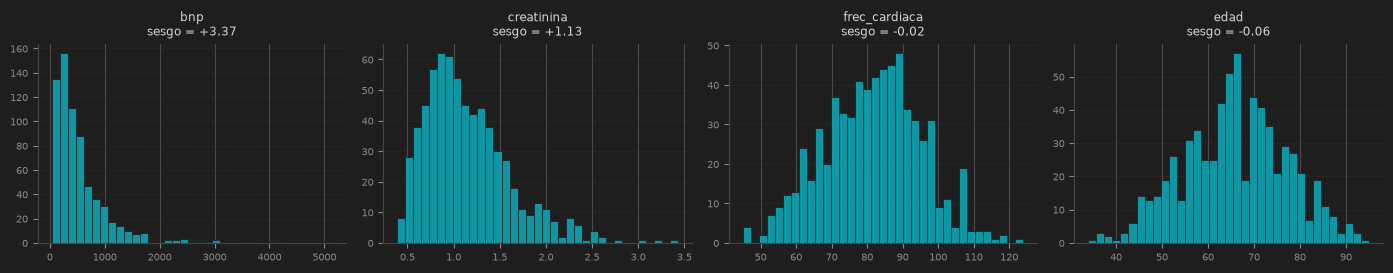

In [14]:
objetivo = ["bnp", "creatinina", "frec_cardiaca", "edad"]
print(perfil(df_tr, objetivo).to_string(index=False))


## ---------------------------------
## Creando los histogramas 
## ---------------------------------
fig, ax = plt.subplots(1, 4, figsize=(14, 2.8), facecolor="#1E1E1E")

for a, v in zip(ax, objetivo):
    a.set_facecolor("#1E1E1E")
    a.hist(
        df_tr[v],
        bins=35,
        color="#0FA3B1",
        edgecolor="#1E1E1E",
        linewidth=0.6,
        alpha=0.9,
    )

    # Título y formato de texto
    sk = stats.skew(df_tr[v])
    a.set_title(
        f"{v}\nsesgo = {sk:+.2f}",
        fontsize=8.5,
        color="#D4D4D4",
        pad=6,
        fontweight="medium",
    )

    # Limpieza de bordes y ticks
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_color("#444444")
    a.spines["bottom"].set_color("#444444")
    a.tick_params(colors="#888888", labelsize=7.5, width=0.8)

    # Cuadrícula sutil
    a.grid(axis="y", color="#333333", linestyle="--", linewidth=0.5, alpha=0.7)
    a.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Tarea.** Decide qué hacer con cada una de las cuatro variables. **No todas requieren lo mismo, y
al menos una no requiere nada.**

In [15]:
# ============================= TU TURNO =============================
# bnp              -> ?
# creatinina       -> ?
# frec_cardiaca    -> ?
# edad             -> ?

# --- bnp: sesgo +3.2, mínimo 33, sin ceros ni negativos -> LOGARITMO
df_tr["bnp"] = np.log(df_tr["bnp"])
df_te["bnp"] = np.log(df_te["bnp"])

# --- creatinina: sesgo ~ +1, mínimo 0.32, dominio positivo -> LOGARITMO
df_tr["creatinina"] = np.log(df_tr["creatinina"])
df_te["creatinina"] = np.log(df_te["creatinina"])

# --- frec_cardiaca: IC 95 % de lambda contiene 1.0 -> NO SE TRANSFORMA
# --- edad: IC 95 % de lambda contiene 1.0 -> NO SE TRANSFORMA

for v in objetivo:
    print("%-18s sesgo tras la decisión: %+.2f" % (v, stats.skew(df_tr[v])))

bnp                sesgo tras la decisión: +0.09
creatinina         sesgo tras la decisión: +0.04
frec_cardiaca      sesgo tras la decisión: -0.02
edad               sesgo tras la decisión: -0.06


> | Variable | Decisión | Evidencia numérica |
> |---|---|---|
> | `bnp` | **Logaritmo** | Sesgo superior a +3, mínimo 33.3, sin ceros ni negativos. λ ≈ 0.00 con IC 95 % [−0.07, +0.06]: la verosimilitud selecciona precisamente la transformación logarítmica. El sesgo posterior cae a ≈ 0.00 |
> | `creatinina` | **Logaritmo** | Sesgo cercano a +1, dominio estrictamente positivo (mínimo 0.32). El sesgo posterior baja a ≈ −0.1 |
> | `frec_cardiaca` | **No se transforma** | Sesgo ≈ +0.09, ya simétrica. λ ≈ 0.79 con **IC 95 % que contiene 1.0** |
> | `edad` | **No se transforma** | Sesgo ≈ −0.06, ya simétrica. λ ≈ 1.09 con **IC 95 % que contiene 1.0** |
>
> Dos de las cuatro variables **no requieren transformación alguna**. Aplicarles una añadiría una capa que
> dificulta la interpretación clínica sin ganancia estadística demostrable. La restricción también es una decisión.
</div>

---
## Punto 7 — Escalamiento
*Subtema 4.6*

In [16]:
num_final = ["edad", "frec_cardiaca", "presion_sistolica", "bnp", "creatinina", "colesterol_total"]
print(df_tr[num_final].describe().T[["mean", "std", "min", "50%", "max"]].round(2).to_string())
print("\nSesgo residual:")
print(df_tr[num_final].apply(lambda s: round(float(stats.skew(s)), 2)).to_string())

                     mean    std    min     50%     max
edad                65.84  11.29  34.00   66.00   95.00
frec_cardiaca       81.54  13.64  45.00   82.00  124.00
presion_sistolica  128.27  18.74  80.00  127.00  185.00
bnp                  5.94   0.82   3.55    5.94    8.55
creatinina           0.06   0.39  -0.94    0.06    1.23
colesterol_total   196.37  39.69  90.00  199.00  322.00

Sesgo residual:
edad                -0.06
frec_cardiaca       -0.02
presion_sistolica    0.21
bnp                  0.09
creatinina           0.04
colesterol_total    -0.13


**Tarea.** Escala las variables numéricas.

> Pregúntale al dato: *¿queda alguna cola pesada que arrastraría la media y la desviación estándar?*

In [17]:
# ============================= TU TURNO =============================

# Tras el Punto 6 no quedan colas pesadas: los sesgos residuales son pequeños.
# StandardScaler es adecuado para todas. Ajuste SOLO en entrenamiento.
escalador = StandardScaler().fit(df_tr[num_final])
df_tr[num_final] = escalador.transform(df_tr[num_final])
df_te[num_final] = escalador.transform(df_te[num_final])

print(df_tr[num_final].describe().T[["mean", "std", "min", "max"]].round(2).to_string())

                   mean  std   min   max
edad               -0.0  1.0 -2.82  2.59
frec_cardiaca       0.0  1.0 -2.68  3.12
presion_sistolica  -0.0  1.0 -2.58  3.03
bnp                 0.0  1.0 -2.90  3.17
creatinina         -0.0  1.0 -2.58  3.00
colesterol_total    0.0  1.0 -2.68  3.17


> Tras el Punto 6 todos los sesgos residuales son pequeños y **ninguna variable conserva una cola pesada**.
> `StandardScaler` —media y desviación estándar— es apropiado, y produce variables comparables entre sí,
> que es lo que la regresión logística regularizada necesita.
>
> El escalador se ajusta **solo con entrenamiento** y se aplica a ambos conjuntos con el mismo objeto ya ajustado.
</div>

---
## Punto 8 — Entrenamiento y elección de la métrica
*Subtemas 3.5 y 3.1*

In [18]:
descartar = ["id_paciente", "reingreso_30d"]
X_tr = df_tr.drop(columns=[c for c in descartar if c in df_tr.columns])
X_te = df_te.drop(columns=[c for c in descartar if c in df_te.columns])
y_tr, y_te = df_tr["reingreso_30d"], df_te["reingreso_30d"]

assert X_tr.select_dtypes(exclude=np.number).empty, "Quedan columnas no numéricas"
print("Matriz final -> train:", X_tr.shape, "| test:", X_te.shape)
print("Prevalencia en prueba: %.4f" % y_te.mean())

modelo = LogisticRegression(solver="lbfgs", max_iter=3000, random_state=SEMILLA).fit(X_tr, y_tr)
pred = modelo.predict(X_te); prob = modelo.predict_proba(X_te)[:, 1]

print("\n--- MODELO ------------------------------------------------------")
print("Accuracy : %.4f" % accuracy_score(y_te, pred))
print("Recall   : %.4f" % recall_score(y_te, pred))
print("AUC ROC  : %.4f" % roc_auc_score(y_te, prob))
print("\nMatriz de confusión [fila = real, columna = predicho]:")
print(confusion_matrix(y_te, pred))
print("\n", classification_report(y_te, pred, digits=3))
print("--- Referencia: clasificador trivial 'nadie reingresa' ----------")
print("Accuracy : %.4f" % accuracy_score(y_te, np.zeros_like(y_te)))

Matriz final -> train: (675, 12) | test: (225, 12)
Prevalencia en prueba: 0.5067

--- MODELO ------------------------------------------------------
Accuracy : 0.6489
Recall   : 0.6228
AUC ROC  : 0.7579

Matriz de confusión [fila = real, columna = predicho]:
[[75 36]
 [43 71]]

               precision    recall  f1-score   support

           0      0.636     0.676     0.655       111
           1      0.664     0.623     0.643       114

    accuracy                          0.649       225
   macro avg      0.650     0.649     0.649       225
weighted avg      0.650     0.649     0.649       225

--- Referencia: clasificador trivial 'nadie reingresa' ----------
Accuracy : 0.4933


**Tarea.** Responde en prosa:

1. Compara la accuracy del modelo con la del clasificador trivial. ¿Cuánto aporta el modelo?
2. ¿Qué métrica reportarías aquí, y por qué?

> **1.** El clasificador trivial alcanza una accuracy cercana a **0.49**, porque la prevalencia de reingreso ronda
> el **50 %**. El modelo la supera con claridad, de modo que **aquí la accuracy sí es informativa**: la ganancia
> sobre el trivial es real y no un artefacto del desbalance.
>
> **2.** Se reportan **accuracy, recall y AUC** en conjunto. Con clases balanceadas la accuracy es interpretable,
> pero el recall sigue importando clínicamente: mide a cuántos de los pacientes que efectivamente reingresaron
> logramos identificar, que es la pregunta operativa del hospital.
>
> **La regla general:** la accuracy solo es interpretable **después** de compararla con el clasificador trivial.
> Esa comparación debe hacerse siempre, no solo cuando se sospecha desbalance.
</div>

---
# Retos finales

<div style="border-left:5px solid #E8912B;background:rgba(232, 145, 43, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#F5B041;">Cambio de formato</b><br>Los dos retos siguientes presentan variables donde <b>la respuesta de hoy no aplica</b>. Este es el tipo de reactivo que aparecer&aacute; en el examen. Resu&eacute;lvelos aunque no alcance el tiempo de clase.
</div>

## Reto A — Una variable con sesgo izquierdo

`fevi_ingreso` (fracción de eyección) es la variable que reservamos al inicio.

sesgo: -0.82
rango: [18, 66]


lambda = +2.19   IC 95% = [+1.95, +2.44]


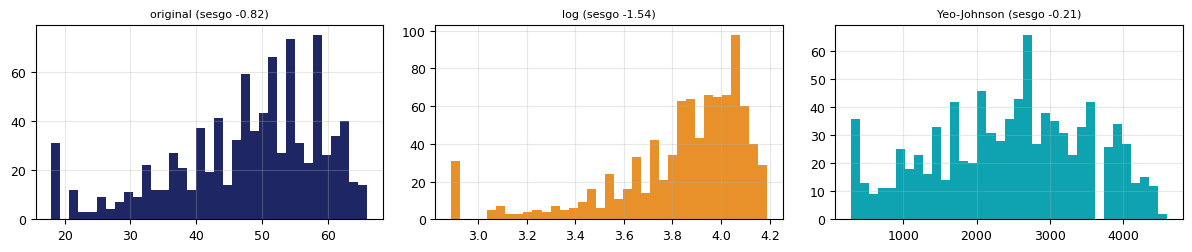

In [19]:
crudo = cargar("cohorte_ic_repaso.csv")
fevi = crudo["fevi_ingreso"]

print("sesgo:", round(float(stats.skew(fevi)), 2))
print("rango: [%.0f, %.0f]" % (fevi.min(), fevi.max()))
lam, lo, hi = lambda_ic(fevi)
print("lambda = %+.2f   IC 95%% = [%+.2f, %+.2f]" % (lam, lo, hi))

fig, ax = plt.subplots(1, 3, figsize=(12, 2.6))
ax[0].hist(fevi, bins=35, color="#1E2664"); ax[0].set_title(f"original (sesgo {stats.skew(fevi):+.2f})", fontsize=8)
ax[1].hist(np.log(fevi), bins=35, color="#E8912B"); ax[1].set_title(f"log (sesgo {stats.skew(np.log(fevi)):+.2f})", fontsize=8)
yj = stats.yeojohnson(fevi.to_numpy(float))[0]
ax[2].hist(yj, bins=35, color="#0FA3B1"); ax[2].set_title(f"Yeo-Johnson (sesgo {stats.skew(yj):+.2f})", fontsize=8)
plt.tight_layout(); plt.show()

**Preguntas.**

1. ¿El logaritmo corrige el sesgo de esta variable? Mira el histograma central y su cifra de sesgo.
2. ¿Por qué λ resulta **mayor** que 1 aquí, cuando en `bnp` resultó ≈ 0?
3. Formula la regla general en una frase.

> **Tu respuesta:**

<br>

> **Respuesta.**
>
> **1. No.** El sesgo original es **negativo (≈ −0.82)**: la cola larga está a la **izquierda**. El logaritmo
> comprime los valores altos, es decir, actúa sobre la cola **derecha**. Aplicado aquí **agrava** el problema en
> lugar de corregirlo, como muestra el histograma central: el sesgo se vuelve más negativo.
>
> **2.** Porque λ y la dirección del sesgo están ligados. En la escalera de potencias, **λ < 1 comprime la cola
> derecha** (corrige sesgo derecho) y **λ > 1 expande hacia arriba** (corrige sesgo izquierdo). En `bnp`, con
> sesgo +3.17, la verosimilitud eligió λ ≈ 0, que es el logaritmo. Aquí, con sesgo −0.82, eligió **λ ≈ 2.19**,
> por encima de 1. El algoritmo no está haciendo nada extraño: está **subiendo** la escalera en lugar de bajarla.
>
> **3.** *El sesgo por sí solo no dicta la transformación: hay que leer su **dirección**, comprobar que el
> **dominio** admita la operación elegida, y verificar con el IC de λ que la corrección sea **necesaria**.*


## Reto B — Una variable con valores negativos

In [20]:
# Variable derivada: desviación del BNP respecto al umbral clínico de referencia (400 pg/mL)
delta_bnp = crudo["bnp"] - 400

print("sesgo:", round(float(stats.skew(delta_bnp)), 2))
print("mínimo: %.1f  |  negativos: %d  |  ceros: %d"
      % (delta_bnp.min(), int((delta_bnp < 0).sum()), int((delta_bnp == 0).sum())))

print("\n¿Qué ocurre si aplicamos np.log() ?")
with np.errstate(invalid="ignore", divide="ignore"):
    intento = np.log(delta_bnp)
print("  valores no finitos generados:", int((~np.isfinite(intento)).sum()), "de", len(delta_bnp))

sesgo: 3.17
mínimo: -366.7  |  negativos: 480  |  ceros: 0

¿Qué ocurre si aplicamos np.log() ?
  valores no finitos generados: 480 de 900


**Tarea.** El sesgo es positivo y fuerte, así que "hay que transformar". Pero `np.log()` destruye
la mayor parte de la columna.

Aplica la transformación adecuada y comprueba el sesgo resultante.


In [21]:
# ============================= TU TURNO =============================

# El dominio incluye negativos y ceros -> el logaritmo es imposible.
# Yeo-Johnson admite el dominio completo.
pt = PowerTransformer(method="yeo-johnson", standardize=False)
delta_yj = pt.fit_transform(delta_bnp.to_frame())[:, 0]

print("lambda estimada: %+.3f" % pt.lambdas_[0])
print("sesgo original : %+.2f" % stats.skew(delta_bnp))
print("sesgo tras YJ  : %+.2f" % stats.skew(delta_yj))
print("valores no finitos:", int((~np.isfinite(delta_yj)).sum()))

lambda estimada: +0.856
sesgo original : +3.17
sesgo tras YJ  : +0.42
valores no finitos: 0


> **Tu conclusión en una frase:**

<br>

> **Conclusión.**
>
> El logaritmo genera `NaN` o `-inf` en cerca de la mitad de las filas, porque **su dominio exige valores
> estrictamente positivos**. Yeo-Johnson está definido para todo el eje real —negativos, cero y positivos— y
> corrige el sesgo sin perder una sola observación.
>
> **La regla:** antes de elegir una transformación, revisa el **mínimo** y el **conteo de negativos y ceros**.
> Si hay alguno, el logaritmo queda descartado sin más discusión.
</div>

---
# Mapa de decisiones — guía de estudio

**Esta tabla es lo que debes estudiar.** No las celdas de código: **las preguntas de la columna central**.

| # | Punto de decisión | La pregunta que le haces al dato | Hoy la respuesta fue |
|---|---|---|---|
| 1 | Integridad y segregación | ¿La fila y la unidad de observación son la misma cosa? | Sí (900 filas = 900 pacientes) → partición estándar |
| 2 | Variables admisibles | ¿Alguna variable se registra **después** del desenlace? | No → no se elimina nada |
| 3 | Atípicos | ¿Este valor es **raro** o es **imposible**? | Colesterol 0 = imposible (corregir) · BNP alto = real (conservar) |
| 4 | Faltantes | ¿El **hecho de que falte** me dice algo? | No (MCAR) → imputación simple, sin indicador |
| 5 | Codificación | ¿Los niveles tienen un **orden monótono** verificable? | No → one-hot para las tres |
| 6 | Corrección del sesgo | ¿Qué **dirección**? ¿El **dominio** admite log? ¿El **IC de λ** excluye a 1? | Log en `bnp` y `creatinina` · sin transformar en las otras dos |
| 7 | Escalamiento | ¿Queda alguna **cola pesada** que arrastre la media? | No → `StandardScaler` |
| 8 | Métrica | ¿Cuánto supero al **clasificador trivial**? | Bastante (≈ 50 % de prevalencia) → accuracy interpretable |

### En el examen

Los ocho puntos serán **los mismos** y en **el mismo orden**. El conjunto de datos será distinto, y por eso
**varias respuestas de la última columna serán otras**. El examen es enteramente práctico y dura 90 minutos.

Se te calificará en tres componentes por punto: **ejecución** (el código corre), **decisión** (elegiste lo que
el dato exige) y **justificación** (citaste la evidencia numérica). Una decisión correcta sin evidencia que la
respalde vale la mitad, y una decisión equivocada que tú mismo detectes y corrijas conserva puntaje parcial.

### Lista de verificación antes del examen

- [ ] Sé comprobar si hay registros duplicados por sujeto, y qué hacer si los hay.
- [ ] Sé distinguir un error de captura de un valor extremo clínicamente válido.
- [ ] Sé comparar el perfil de los casos con y sin dato faltante para decidir si la ausencia es informativa.
- [ ] Sé verificar si una variable categórica tiene orden monótono antes de codificarla.
- [ ] Sé leer la **dirección** del sesgo, no solo su magnitud.
- [ ] Sé revisar el mínimo y el conteo de negativos antes de intentar un logaritmo.
- [ ] Sé interpretar el IC 95 % de λ para decidir **no** transformar.
- [ ] Sé calcular el desempeño del clasificador trivial y comparar contra él.
